### SIMPLE RNN ARCHITECTURE 

In [1]:
import numpy as np
import os
import librosa
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

def extract_features(file_path):
    audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_processed = np.mean(mfccs.T, axis=0)
    return mfccs_processed

def load_data(data_path):
    features = []
    labels = []
    
    for folder in os.listdir(data_path):
        if folder.startswith('.'):
            continue
        class_label = folder
        class_dir = os.path.join(data_path, class_label)
        
        for file in os.listdir(class_dir):
            if file.endswith('.wav'):
                file_path = os.path.join(class_dir, file)
                data = extract_features(file_path)
                features.append(data)
                labels.append(class_label)
    
    features = np.array(features)
    labels = np.array(labels)
    
    return features, labels

# Example usage
data_path = 'E:/SARAVANAN-2024-2025/STUDENT OWN CONCEPT/B1302/DEEP FAKE DETECTION/RESOURCES/Deepfake_detection_using_deep_learning-master/DATASET/TRAIN/'
X, y = load_data(data_path)


# Encode the labels
le = LabelEncoder()
y_encoded = to_categorical(le.fit_transform(y))

# Reshape X for the RNN model
X_reshaped = X.reshape(X.shape[0], X.shape[1], 1)

# Build the SimpleRNN model
model_rnn = Sequential()
model_rnn.add(SimpleRNN(128, input_shape=(X_reshaped.shape[1], 1), return_sequences=True))
model_rnn.add(Dropout(0.3))
model_rnn.add(SimpleRNN(128))
model_rnn.add(Dropout(0.3))
model_rnn.add(Dense(y_encoded.shape[1], activation='softmax'))

model_rnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_rnn.summary()

# Train the SimpleRNN model
history_rnn = model_rnn.fit(X_reshaped, y_encoded, epochs=10, batch_size=512, validation_split=0.3)



C:\Users\SPIRO-PYTHON1\AppData\Local\Temp\ipykernel_11732\3088365987.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 40, 128)           16640     
                                                                 
 dropout (Dropout)           (None, 40, 128)           0         
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense (Dense)               (None, 2)                 258       
                                                                 
Total params: 49794 (194.51 KB)
Trainable params: 49794 (194.51 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
2/2 [==

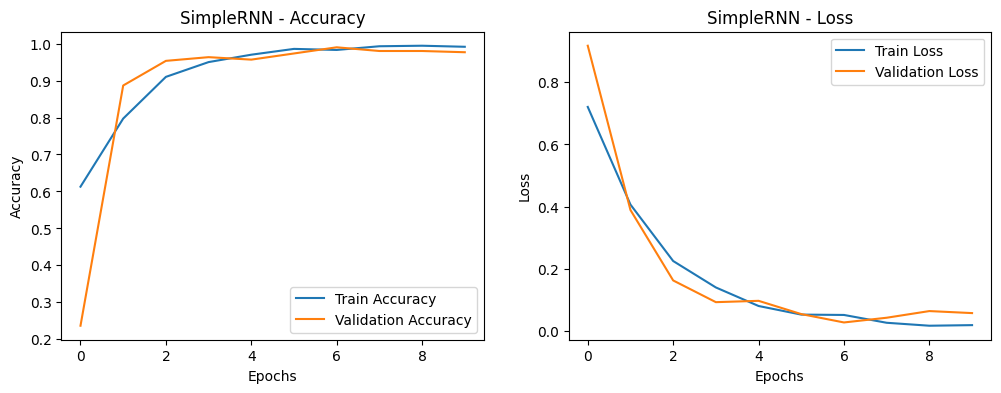

In [2]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()



# Visualize SimpleRNN model training history
plot_history(history_rnn, 'SimpleRNN')



